In [1]:
import os
import csv
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

cwd = os.getcwd()
root = os.path.dirname(cwd) if cwd.endswith('/code') else cwd
FIG_DIR = root + '/paper/figures'
os.makedirs(FIG_DIR, exist_ok=True)

with open(root + '/artifacts/results_grid.csv', newline='', encoding='utf-8') as f:
    rows = list(csv.DictReader(f))

buckets = defaultdict(lambda: {'lv': [], 'mu': [], 'L': None, 'E': None})
for r in rows:
    key = (r['model_id'], int(r['train_tokens_real']))
    buckets[key]['lv'].append(float(r['val_loss']))
    buckets[key]['mu'].append(float(r['mu_landscape']))
    buckets[key]['L'] = int(r['n_layer'])
    buckets[key]['E'] = int(r['n_embd'])
agg = []
for (mid, tok), d in sorted(buckets.items()):
    agg.append(
        {
            'model_id': mid,
            'tokens': tok,
            'lv': float(np.mean(d['lv'])),
            'mu': float(np.mean(d['mu'])),
            'L': d['L'],
            'E': d['E'],
        }
    )

lv = np.array([p['lv'] for p in agg])
logt = np.log(np.maximum(np.array([p['tokens'] for p in agg], dtype=float), 1.0))
mu = np.array([p['mu'] for p in agg])
X = np.column_stack([np.ones(len(agg)), lv, logt])
beta, _, _, _ = np.linalg.lstsq(X, mu, rcond=None)
resid = mu - X @ beta
ss_res = float(np.sum(resid**2))
ss_tot = float(np.sum((mu - np.mean(mu)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float('nan')
print(f'Grid CSV: {len(rows)} rows, {len(set(r["model_id"] for r in rows))} model_id')
print(f'Pooled OLS on grid (mean over seeds): R^2={r2:.4f}, beta={beta}')

by_ms = defaultdict(list)
for r in rows:
    by_ms[(r['model_id'], int(r['seed']))].append(
        (int(r['train_tokens_real']), float(r['val_loss']), float(r['mu_landscape']))
    )
neg_dl_pairs = 0
neg_dl_pos_dmu = 0
for pts in by_ms.values():
    pts = sorted(pts, key=lambda x: x[0])
    for i in range(len(pts) - 1):
        dlv = pts[i + 1][1] - pts[i][1]
        dmu = pts[i + 1][2] - pts[i][2]
        if dlv < 0:
            neg_dl_pairs += 1
            if dmu > 0:
                neg_dl_pos_dmu += 1
frac = neg_dl_pos_dmu / neg_dl_pairs if neg_dl_pairs else float('nan')

Grid CSV: 5760 rows, 36 model_id
Pooled OLS on grid (mean over seeds): R^2=0.2667, beta=[ 0.55852725 -0.03534106 -0.01387934]


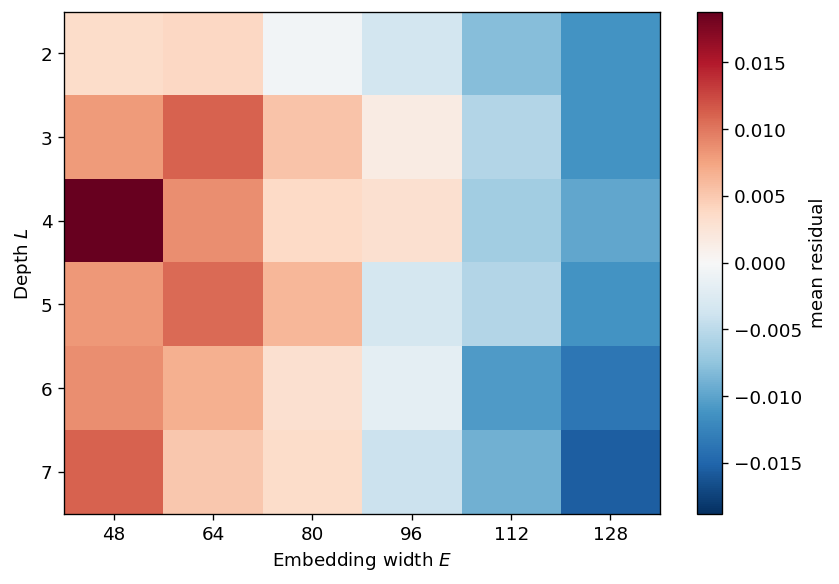

In [2]:
depths = sorted({p['L'] for p in agg})
widths = sorted({p['E'] for p in agg})
d_idx = {d: i for i, d in enumerate(depths)}
w_idx = {w: i for i, w in enumerate(widths)}
acc = defaultdict(float)
cnt = defaultdict(int)
for p, r in zip(agg, resid):
    key = (p['L'], p['E'])
    acc[key] += float(r)
    cnt[key] += 1
mat = np.full((len(depths), len(widths)), np.nan)
for (L, E), s in acc.items():
    mat[d_idx[L], w_idx[E]] = s / cnt[(L, E)]

fig, ax = plt.subplots(figsize=(7.2, 5))
vmax = np.nanmax(np.abs(mat))
im = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(np.arange(len(widths)), labels=[str(w) for w in widths])
ax.set_yticks(np.arange(len(depths)), labels=[str(d) for d in depths])
ax.set_xlabel(r'Embedding width $E$')
ax.set_ylabel(r'Depth $L$')
plt.colorbar(im, ax=ax, label=r'mean residual')
fig.tight_layout()
out_path = root + '/paper/figures/fig_grid_mu_residual_heatmap.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
